
# Two-color TIFF hyperstack presentation rendering

This notebook loads a two-channel TIFF hyperstack (for example, an ImageJ/Fiji hyperstack made by combining
`dmd1_warped_ch1.tif` and `dmd2_warped_ch1.tif`) and creates presentation-ready visualizations.

It is designed for the case where:

- **channel 0 / channel 1** correspond to the two merged SLAP2 sub-volumes,
- one channel should be rendered in a **warm red/salmon** color,
- the other should be rendered in **dodger blue**,
- the output should be a clean, oblique, side-view figure suitable for slides.

The notebook includes:

1. robust hyperstack loading,
2. channel extraction regardless of common TIFF axis order,
3. quick QC projections,
4. an oblique colored rendering,
5. slide-ready export to PNG / PDF / transparent PNG.


In [9]:

from pathlib import Path
import json
import os
import warnings

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy.ndimage import gaussian_filter, rotate, zoom
from vip_slap2_analysis.utils.utils import save_figure

warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['figure.facecolor'] = 'black'


## 1. Configure input / output paths

In [2]:

# --- REQUIRED: set INPUT_TIF to your two-color hyperstack ---
INPUT_TIF = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\slap2_super_stack_ch1_two_color.tif")

# Optional: set a custom output directory. By default, figures go next to the input TIFF.
OUT_DIR = INPUT_TIF.parent / "presentation_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_TIF:", INPUT_TIF)
print("OUT_DIR:", OUT_DIR)


INPUT_TIF: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\slap2_super_stack_ch1_two_color.tif
OUT_DIR: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\presentation_figures


## 2. Rendering parameters

In [3]:

# Channel colors.
CH0_COLOR = "#F29B7B"   # warm salmon / red-orange
CH1_COLOR = "#1E90FF"   # dodger blue

# Approximate sampling for annotation / z scaling.
XY_UM_PER_PX = 0.25
Z_UM_PER_PLANE = 1.50

# Intensity / enhancement parameters.
BACKGROUND_SUBTRACT = True
BACKGROUND_SIGMA_YX = 10
LOW_Q = 5.0
HIGH_Q = 99.99
GAMMA = 1
SIGNAL_FLOOR = 0.01
PROJECTION_GAIN = 1.0

# View controls.
DOWNSAMPLE_XY = 1
Z_SCALE_BOOST = 1
TILT_X_DEG = 18
TILT_Z_DEG = -20
SMOOTH_SIGMA = 0.25
CROP_THRESHOLD = 0.01


## 3. Helper functions

In [4]:

def load_two_channel_hyperstack(path):
    """Load a TIFF hyperstack and return (ch0, ch1, axes, raw_shape).

    Supports common TIFF axis conventions such as:
    - CZYX
    - ZCYX
    - TCZYX / TZCYX (first frame used if T present)
    - CYX with a single-plane stack (not ideal but handled)
    """
    path = Path(path)
    with tifffile.TiffFile(path) as tif:
        series = tif.series[0]
        arr = series.asarray()
        axes = series.axes

    arr = np.asarray(arr)
    raw_shape = arr.shape

    # Handle a time axis by taking the first time point.
    if 'T' in axes:
        tidx = axes.index('T')
        arr = np.take(arr, 0, axis=tidx)
        axes = axes.replace('T', '')

    # Squeeze singleton axes except channel if possible.
    squeeze_axes = []
    new_axes = []
    for ax, size in zip(axes, arr.shape):
        if size == 1 and ax != 'C':
            continue
        new_axes.append(ax)
    arr = np.squeeze(arr)
    axes = ''.join(new_axes)

    # If squeeze collapsed everything, reconstruct from arr.ndim where possible.
    if 'C' not in axes:
        raise ValueError(f"Could not find channel axis in TIFF axes: {axes!r}, shape={raw_shape}")

    cidx = axes.index('C')
    arr = np.moveaxis(arr, cidx, 0)

    if arr.shape[0] < 2:
        raise ValueError(f"Expected at least 2 channels, found shape {arr.shape} from axes {axes!r}")

    # Now expect channel-first. Reorder remaining axes to ZYX where possible.
    rem_axes = axes[:cidx] + axes[cidx+1:]

    # Common cases after moving channel first.
    if rem_axes == 'ZYX':
        pass
    elif rem_axes == 'YX':
        arr = arr[:, None, :, :]
        rem_axes = 'ZYX'
    else:
        # Build mapping for Z, Y, X if present.
        needed = ['Z', 'Y', 'X']
        if not all(ax in rem_axes for ax in ['Y', 'X']):
            raise ValueError(f"Could not map remaining axes {rem_axes!r} to ZYX")
        order = []
        for ax in needed:
            if ax in rem_axes:
                order.append(rem_axes.index(ax) + 1)  # +1 because channel axis is first
            elif ax == 'Z':
                arr = arr[:, None, ...]
                rem_axes = 'Z' + rem_axes
                order = [1]  # restart
                for ax2 in ['Y', 'X']:
                    order.append(rem_axes.index(ax2) + 1)
                break
        arr = np.transpose(arr, (0,) + tuple(order))

    ch0 = arr[0].astype(np.float32)
    ch1 = arr[1].astype(np.float32)
    return ch0, ch1, axes, raw_shape


def robust_img_for_display(img, q_low=1.0, q_high=99.7):
    img = np.asarray(img, dtype=np.float32)
    vals = img[np.isfinite(img) & (img > 0)]
    if vals.size == 0:
        return np.zeros_like(img, dtype=np.float32)
    lo, hi = np.percentile(vals, [q_low, q_high])
    if hi <= lo:
        hi = lo + 1e-6
    out = np.clip((img - lo) / (hi - lo), 0, 1)
    return out.astype(np.float32)


def enhance_structural_volume(
    vol,
    *,
    background_subtract=True,
    background_sigma_yx=10,
    low_q=5.0,
    high_q=99.8,
    gamma=0.60,
    signal_floor=0.01,
):
    vol = np.asarray(vol, dtype=np.float32)
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0)

    if background_subtract:
        bg = gaussian_filter(vol, sigma=(0, background_sigma_yx, background_sigma_yx))
        vol = vol - bg
        vol[vol < 0] = 0

    vals = vol[vol > 0]
    if vals.size == 0:
        return np.zeros_like(vol, dtype=np.float32)

    lo, hi = np.percentile(vals, [low_q, high_q])
    if hi <= lo:
        hi = lo + 1e-6

    out = np.clip((vol - lo) / (hi - lo), 0, 1)
    out = out ** gamma
    out[out < signal_floor] = 0
    return out.astype(np.float32)


def bbox_from_union(vol1, vol2, threshold=0.01, pad=(4, 16, 16)):
    m = (vol1 > threshold) | (vol2 > threshold)
    coords = np.argwhere(m)
    if coords.size == 0:
        return tuple(slice(0, s) for s in vol1.shape)
    mins = coords.min(axis=0)
    maxs = coords.max(axis=0) + 1
    mins = np.maximum(mins - np.array(pad), 0)
    maxs = np.minimum(maxs + np.array(pad), np.array(vol1.shape))
    return tuple(slice(int(a), int(b)) for a, b in zip(mins, maxs))


def oblique_mip_render(
    ch0,
    ch1,
    *,
    ch0_color="#F29B7B",
    ch1_color="#1E90FF",
    xy_um=0.25,
    z_um=1.50,
    background_subtract=True,
    background_sigma_yx=10,
    low_q=5.0,
    high_q=99.8,
    gamma=0.60,
    signal_floor=0.01,
    projection_gain=3.0,
    downsample_xy=2,
    z_scale_boost=0.45,
    tilt_x_deg=18,
    tilt_z_deg=-20,
    smooth_sigma=0.25,
    crop_threshold=0.01,
):
    v0 = enhance_structural_volume(
        ch0,
        background_subtract=background_subtract,
        background_sigma_yx=background_sigma_yx,
        low_q=low_q,
        high_q=high_q,
        gamma=gamma,
        signal_floor=signal_floor,
    )
    v1 = enhance_structural_volume(
        ch1,
        background_subtract=background_subtract,
        background_sigma_yx=background_sigma_yx,
        low_q=low_q,
        high_q=high_q,
        gamma=gamma,
        signal_floor=signal_floor,
    )

    bb = bbox_from_union(v0, v1, threshold=crop_threshold)
    v0 = v0[bb]
    v1 = v1[bb]

    if downsample_xy and downsample_xy > 1:
        factors = (1.0, 1.0 / downsample_xy, 1.0 / downsample_xy)
        v0 = zoom(v0, factors, order=1)
        v1 = zoom(v1, factors, order=1)
        xy_um = xy_um * downsample_xy

    z_factor = (z_um / xy_um) * z_scale_boost
    if z_factor != 1.0:
        v0 = zoom(v0, (z_factor, 1.0, 1.0), order=1)
        v1 = zoom(v1, (z_factor, 1.0, 1.0), order=1)

    if smooth_sigma and smooth_sigma > 0:
        v0 = gaussian_filter(v0, smooth_sigma)
        v1 = gaussian_filter(v1, smooth_sigma)

    # Rotate to oblique view.
    v0r = rotate(v0, angle=tilt_x_deg, axes=(0, 1), reshape=True, order=1, mode='constant', cval=0)
    v1r = rotate(v1, angle=tilt_x_deg, axes=(0, 1), reshape=True, order=1, mode='constant', cval=0)
    v0r = rotate(v0r, angle=tilt_z_deg, axes=(1, 2), reshape=True, order=1, mode='constant', cval=0)
    v1r = rotate(v1r, angle=tilt_z_deg, axes=(1, 2), reshape=True, order=1, mode='constant', cval=0)

    # MIP through the viewing axis.
    p0 = np.max(v0r, axis=1)
    p1 = np.max(v1r, axis=1)

    p0 = np.clip(p0 * projection_gain, 0, 1)
    p1 = np.clip(p1 * projection_gain, 0, 1)

    c0 = np.asarray(to_rgb(ch0_color), dtype=np.float32)
    c1 = np.asarray(to_rgb(ch1_color), dtype=np.float32)

    rgb = np.zeros(p0.shape + (3,), dtype=np.float32)
    rgb += p0[..., None] * c0[None, None, :]
    rgb += p1[..., None] * c1[None, None, :]
    rgb = np.clip(rgb, 0, 1)

    return {
        'rgb': rgb,
        'p0': p0,
        'p1': p1,
        'crop_bbox': bb,
        'xy_um_effective': xy_um,
        'z_factor_used': z_factor,
    }


## 4. Load the two-channel hyperstack

In [5]:

ch0, ch1, axes, raw_shape = load_two_channel_hyperstack(INPUT_TIF)
print('Raw TIFF shape:', raw_shape)
print('Raw TIFF axes :', axes)
print('Channel 0 volume:', ch0.shape, ch0.dtype)
print('Channel 1 volume:', ch1.shape, ch1.dtype)


Raw TIFF shape: (176, 2, 1413, 1549)
Raw TIFF axes : ZCYX
Channel 0 volume: (176, 1413, 1549) float32
Channel 1 volume: (176, 1413, 1549) float32


## 5. Quick QC projections

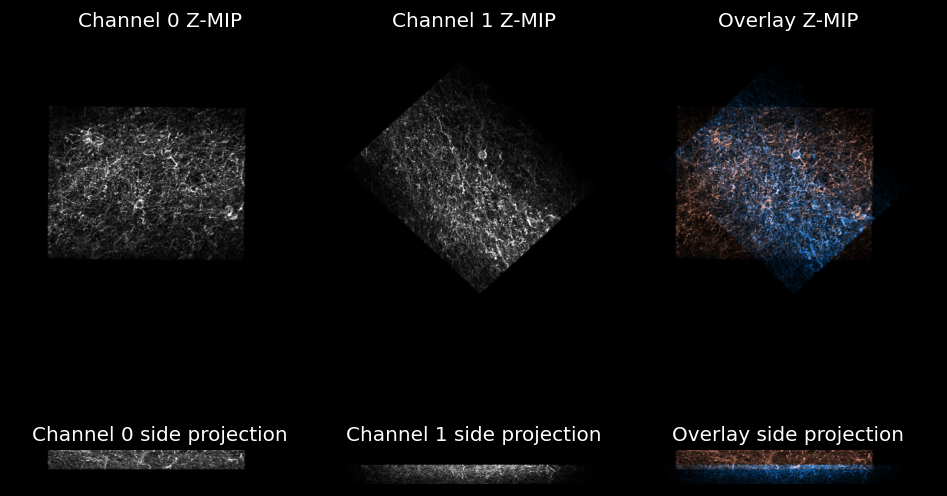

In [11]:

def mip(vol, axis=0):
    tmp = np.where(np.isfinite(vol), vol, 0)
    return tmp.max(axis=axis)

z0 = robust_img_for_display(mip(ch0, axis=0))
z1 = robust_img_for_display(mip(ch1, axis=0))
y0 = robust_img_for_display(mip(ch0, axis=1))
y1 = robust_img_for_display(mip(ch1, axis=1))

c0 = np.asarray(to_rgb(CH0_COLOR), dtype=np.float32)
c1 = np.asarray(to_rgb(CH1_COLOR), dtype=np.float32)

rgb_z = np.clip(z0[..., None] * c0 + z1[..., None] * c1, 0, 1)
rgb_y = np.clip(y0[..., None] * c0 + y1[..., None] * c1, 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(8, 6), facecolor='black')
for ax in axes.ravel():
    ax.set_facecolor('black')

panels = [
    ('Channel 0 Z-MIP', z0, 'gray'),
    ('Channel 1 Z-MIP', z1, 'gray'),
    ('Overlay Z-MIP', rgb_z, None),
    ('Channel 0 side projection', y0, 'gray'),
    ('Channel 1 side projection', y1, 'gray'),
    ('Overlay side projection', rgb_y, None),
]

for ax, (title, img, cmap) in zip(axes.ravel(), panels):
    if cmap is None:
        ax.imshow(img)
    else:
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title, color='white')
    ax.axis('off')

fig.tight_layout()
filen = 'super_stack_two-color_MIP'
save_figure(fig,os.path.join(OUT_DIR,filen),formats=['.pdf','.png'],dpi=300)

## 6. Main presentation rendering

FileNotFoundError: [Errno 2] No such file or directory: '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\ASAP7\\826031\\826031_2026-02-04_12-15-34\\826031_2026-02-04_12-15-34\\slap2\\static_data\\super_stack_qc\\full_reference_merge\\presentation_figures\\slap2_super_stack_ch1_two_color_presentation_render_transparent.png'

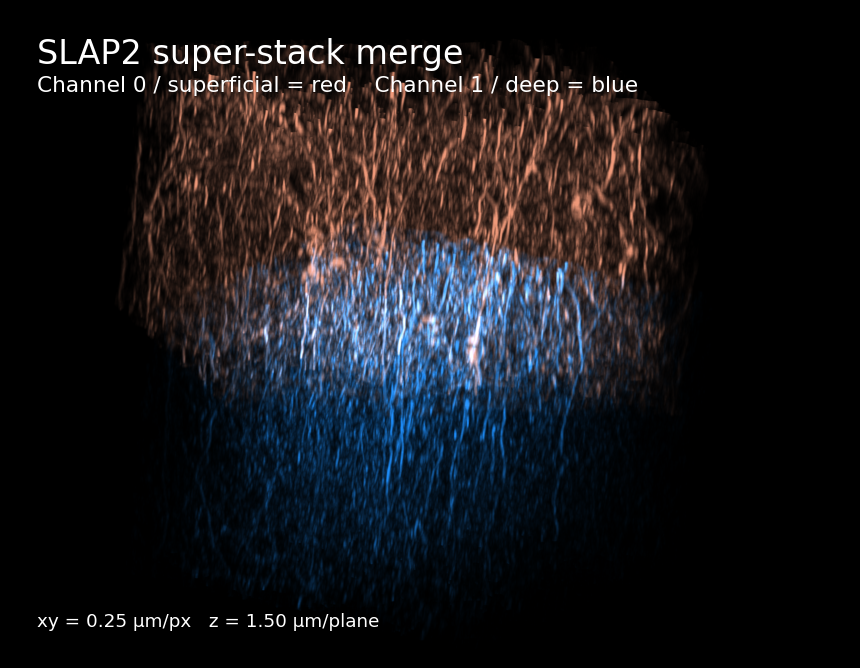

In [12]:
render = oblique_mip_render(
    ch0,
    ch1,
    ch0_color=CH0_COLOR,
    ch1_color=CH1_COLOR,
    xy_um=XY_UM_PER_PX,
    z_um=Z_UM_PER_PLANE,
    background_subtract=BACKGROUND_SUBTRACT,
    background_sigma_yx=BACKGROUND_SIGMA_YX,
    low_q=LOW_Q,
    high_q=HIGH_Q,
    gamma=GAMMA,
    signal_floor=SIGNAL_FLOOR,
    projection_gain=PROJECTION_GAIN,
    downsample_xy=DOWNSAMPLE_XY,
    z_scale_boost=Z_SCALE_BOOST,
    tilt_x_deg=TILT_X_DEG,
    tilt_z_deg=TILT_Z_DEG,
    smooth_sigma=SMOOTH_SIGMA,
    crop_threshold=CROP_THRESHOLD,
)

rgb = render['rgb']

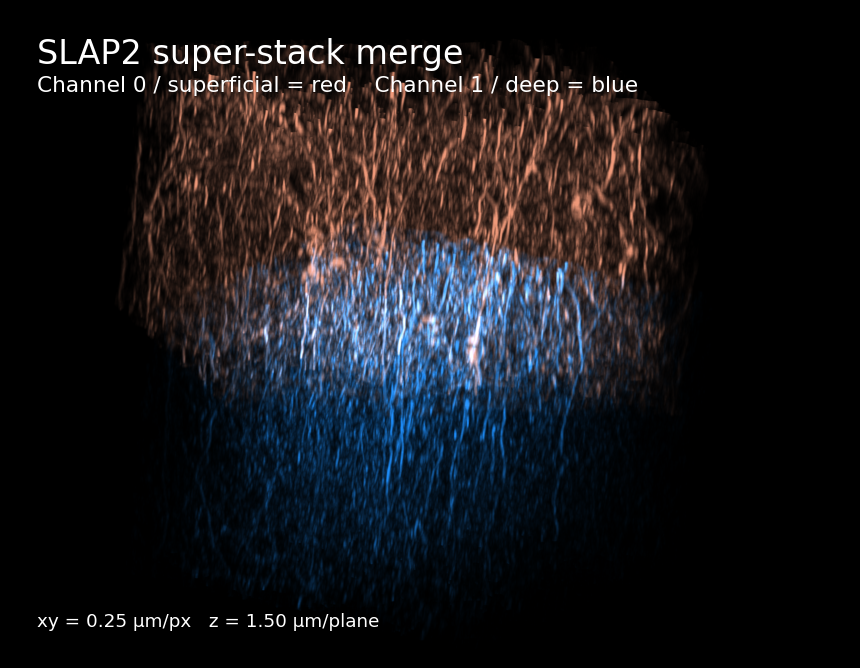

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\presentation_figures\slap2_super_stack_ch1_two_color_presentation_render.png
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\presentation_figures\slap2_super_stack_ch1_two_color_presentation_render.pdf
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34\slap2\static_data\super_stack_qc\full_reference_merge\presentation_figures\slap2_super_stack_ch1_two_color_presentation_render_transparent.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 8), facecolor='black')
ax.set_facecolor('black')
ax.imshow(np.clip(rgb, 0, 1))
ax.axis('off')

ax.text(
    0.03, 0.96,
    'SLAP2 super-stack merge',
    transform=ax.transAxes,
    va='top', ha='left', color='white', fontsize=20,
)

ax.text(
    0.03, 0.90,
    'Channel 0 / superficial = red    Channel 1 / deep = blue',
    transform=ax.transAxes,
    va='top', ha='left', color='white', fontsize=13,
)

ax.text(
    0.03, 0.04,
    f'xy = {XY_UM_PER_PX:.2f} µm/px   z = {Z_UM_PER_PLANE:.2f} µm/plane',
    transform=ax.transAxes,
    va='bottom', ha='left', color='white', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.25', fc=(0,0,0,0.35), ec='none')
)

stem = INPUT_TIF.stem
out_png = OUT_DIR / f'{stem}_presentation_render.png'
out_pdf = OUT_DIR / f'{stem}_presentation_render.pdf'

# fig.savefig(out_png, bbox_inches='tight', pad_inches=0.04, facecolor=fig.get_facecolor())
# fig.savefig(out_pdf, bbox_inches='tight', pad_inches=0.04, facecolor=fig.get_facecolor())

plt.show()
print(out_png)
print(out_pdf)
print(out_transparent)

## 7. Tuning suggestions

In [ ]:

print('If the figure is too dark:')
print('  PROJECTION_GAIN = 5.0')
print('  LOW_Q = 1.0')
print('  GAMMA = 0.40')
print('  SIGNAL_FLOOR = 0.0')
print('  BACKGROUND_SUBTRACT = False')
print()
print('If the figure is too blown out / slab-like:')
print('  PROJECTION_GAIN = 1.5')
print('  LOW_Q = 15.0')
print('  GAMMA = 0.80')
print('  SIGNAL_FLOOR = 0.03')
print('  BACKGROUND_SUBTRACT = True')
print()
print('If the volume looks too thick:')
print('  Z_SCALE_BOOST = 0.30 to 0.40')
print()
print('If you want a more side-on view:')
print('  TILT_X_DEG = 22 to 28')



## Notes

This notebook assumes the TIFF contains **two channels representing the two sub-volumes**.

Unlike the earlier direct-volume notebooks, this version:

- loads the already-combined ImageJ/Fiji hyperstack,
- detects the channel axis,
- assigns each channel a fixed presentation color,
- renders an oblique MIP-style view that is usually robust and slide-friendly.
